In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
load_dotenv()


True

In [23]:
model = ChatMistralAI(model="mistral-small-2506")

In [24]:
# here we will create a system where we will give runs scored, balls faces, total sixes, total fours
# and calculate strikerate, boundry percentage and balls per boundry and this will be calculated parallely

In [25]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    sixes: int
    fours: int
    strikerate: int
    ballsPerBoundry: float
    boundryPercentage: float
    summary: str

In [26]:
def get_sr(state: BatsmanState) -> BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    return {"strikerate" : sr}


def get_bpb(state: BatsmanState) -> BatsmanState:
    bpb = state['balls'] / state['fours'] + state["sixes"]
    # state["ballsPerBoundry"] = bpb
    return {"ballsPerBoundry" : bpb} 


def get_bp(state: BatsmanState) -> BatsmanState:
    bp = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    # state["boundryPercentage"] = bp
    return {"boundryPercentage" : bp}


def summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
    Strike Rate = {state["strikerate"]} \n
    Balls per boundry = {state["ballsPerBoundry"]} \n
    Boundry percent = {state["ballsPerBoundry"]} \n
    """
    # state["summary"] = summary
    return {"summary" : summary}

In [27]:
graph = StateGraph(BatsmanState)

graph.add_node("get_sr", get_sr)
graph.add_node("get_bpb", get_bpb)
graph.add_node("get_bp", get_bp)
graph.add_node("summary", summary)

graph.add_edge(START, "get_sr")
graph.add_edge(START, "get_bpb")
graph.add_edge(START, "get_bp")


graph.add_edge("get_sr", "summary")
graph.add_edge("get_bpb", "summary")
graph.add_edge("get_bp", "summary")
graph.add_edge("summary", END)

workflow = graph.compile()

result = workflow.invoke({
    "runs": 100,
    "balls": 50,
    "fours": 10,
    "sixes": 5
})

print(result)


{'runs': 100, 'balls': 50, 'sixes': 5, 'fours': 10, 'strikerate': 200.0, 'ballsPerBoundry': 10.0, 'boundryPercentage': 70.0, 'summary': '\n    Strike Rate = 200.0 \n\n    Balls per boundry = 10.0 \n\n    Boundry percent = 10.0 \n\n    '}


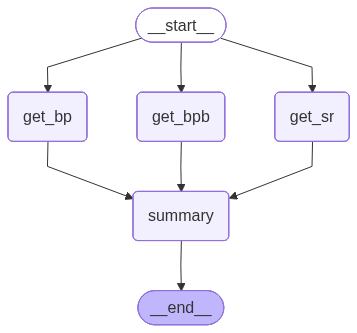

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())